In [2]:
import scipy.io as sio
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt 

**2.1 Alineación de vóxeles entre sujetos**

Para encontrar los vóxeles que existen en todos los sujetos, se utiliza meta.colToCoord, que son las coordenadas MNI de cada columna, para encontrar la intersección de ubicaciones en todos los sujetos. 

Se consigue así que el vóxel n se corresponda en todos los sujetos, para poder calcular ISC.


In [3]:
all_coords = []
all_data = []
all_meta = []

for subj_id in range(1, 9):
    mat = sio.loadmat(f'C:\\Users\\Ale\\subject_{subj_id}.mat', squeeze_me=True)

    # Extraer meta — el manejo de structs de scipy puede requerir ajustes
    meta = mat['meta']
    
    # Handle the meta structure properly
    # If meta is a numpy.ndarray with a structured dtype
    if isinstance(meta, np.ndarray) and meta.dtype.fields is not None:
        # Access the colToCoord field directly
        if 'colToCoord' in meta.dtype.fields:
            coords = np.array(meta['colToCoord'])
        else:
            # If meta is a scalar array containing a struct
            if meta.size == 1:
                meta_item = meta.item()
                if hasattr(meta_item, 'colToCoord'):
                    coords = np.array(meta_item.colToCoord)
                elif isinstance(meta_item, dict) and 'colToCoord' in meta_item:
                    coords = np.array(meta_item['colToCoord'])
                else:
                    raise ValueError(f"Cannot find colToCoord in meta for subject {subj_id}")
            else:
                raise ValueError(f"Unexpected meta structure for subject {subj_id}")
    # If meta is already a dict
    elif isinstance(meta, dict) and 'colToCoord' in meta:
        coords = np.array(meta['colToCoord'])
    else:
        raise ValueError(f"Unexpected meta type for subject {subj_id}: {type(meta)}")
    
    # Ensure coords is a 2D array
    if coords.ndim == 1:
        # If it's a 1D array, reshape it to be 2D with 3 columns
        # This assumes coords is a flattened array of x,y,z coordinates
        coords = coords.reshape(-1, 3)
    elif coords.ndim == 0:
        # If it's a 0D array (scalar), it might contain an object
        coords = np.array(coords.item())
        if coords.ndim == 1:
            coords = coords.reshape(-1, 3)
    
    data = np.load(f'data_subject{subj_id}_clean.npy')

    # Convert coordinates to tuples for set operations
    # Make sure each coordinate is hashable
    coord_list = [tuple(map(float, c)) for c in coords]
    coord_set = set(coord_list)
    
    all_coords.append((coords, coord_set))
    all_data.append(data)
    all_meta.append(meta)

    print(f"Sujeto {subj_id}: {len(coord_set)} vóxeles")

# Intersección: solo ubicaciones presentes en los 8 sujetos
common_set = all_coords[0][1]
for _, cs in all_coords[1:]:
    common_set = common_set.intersection(cs)

common_coords = sorted(common_set)
print(f"\nVóxeles en intersección (8 sujetos): {len(common_coords)}")

# Extraer datos alineados: para cada sujeto, tomar solo las columnas que corresponden a las coordenadas comunes, en el mismo orden.
subjects_aligned = []
for subj_idx in range(8):
    coords = all_coords[subj_idx][0]
    data = all_data[subj_idx]

    # Create a mapping from coordinate tuples to column indices
    coord_to_col = {}
    for i, c in enumerate(coords):
        coord_to_col[tuple(map(float, c))] = i
    
    # Get column indices for common coordinates
    col_indices = [coord_to_col[c] for c in common_coords]
    subjects_aligned.append(data[:, col_indices])

    print(f"Sujeto {subj_idx+1}: alineado a {subjects_aligned[-1].shape}")

# Ahora subjects_aligned[i] tiene shape (nTRs, n_common_voxels)
# y el vóxel j corresponde a la MISMA ubicación MNI en todos los sujetos.
np.save('common_coords.npy', np.array(common_coords))


Sujeto 1: 37913 vóxeles
Sujeto 2: 33740 vóxeles
Sujeto 3: 29307 vóxeles
Sujeto 4: 26851 vóxeles
Sujeto 5: 27073 vóxeles
Sujeto 6: 34837 vóxeles
Sujeto 7: 30689 vóxeles
Sujeto 8: 31047 vóxeles

Vóxeles en intersección (8 sujetos): 15371
Sujeto 1: alineado a (1351, 15371)
Sujeto 2: alineado a (1351, 15371)
Sujeto 3: alineado a (1351, 15371)
Sujeto 4: alineado a (1351, 15371)
Sujeto 5: alineado a (1351, 15371)
Sujeto 6: alineado a (1351, 15371)
Sujeto 7: alineado a (1351, 15371)
Sujeto 8: alineado a (1351, 15371)


El resultado son 15.371 vóxeles compartidos. Se restrigen los datos a estas ubicaciones MNI y se obtienen matrices de igual tamaño para todos los sujetos (1351 TRs × 15371 vóxeles), lo que garantiza la validez de análisis posteriores.

**2.2 ISC (Inter-Subject Correlation) vectorizada**

Este bloque mide cúanto se parecen las respuestas temporales entre pares de sujetos. Se obtienen 28 correlaciones para los 28 pares, que se promedian utilizando la transformación z de Fisher, que convierte correlaciones a una escala donde se pueden promediar linealmente y luego revertir. 

ISC rango top 10k: [0.0016, 0.0801]
ISC media global: 0.0066


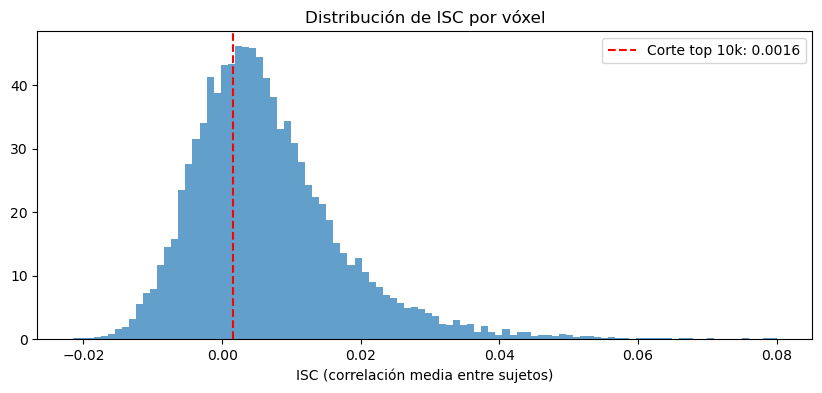

In [4]:
all_stack = np.stack(subjects_aligned)  # (8, nTRs, nVoxels)
pairs = list(combinations(range(8), 2))  # 28 pares
n_voxels = all_stack.shape[2]

isc_fisher_sum = np.zeros(n_voxels)
for i, j in pairs:
    # Correlación de Pearson vectorizada (todos los vóxeles a la vez)
    xi = all_stack[i] - all_stack[i].mean(axis=0, keepdims=True)
    xj = all_stack[j] - all_stack[j].mean(axis=0, keepdims=True)
    num = np.sum(xi * xj, axis=0)
    den = np.sqrt(np.sum(xi**2, axis=0) * np.sum(xj**2, axis=0)) + 1e-10
    r = num / den

    # Transformación z de Fisher: arctanh(r)
    # Necesaria porque la media aritmética de correlaciones está sesgada.
    isc_fisher_sum += np.arctanh(np.clip(r, -0.999, 0.999))

# Revertir Fisher: tanh(media de los z de Fisher)
isc_values = np.tanh(isc_fisher_sum / len(pairs))

# Seleccionar los top 10,000 vóxeles más consistentes
top_10k = np.argsort(isc_values)[-10000:]
print(f"ISC rango top 10k: [{isc_values[top_10k].min():.4f}, "
      f"{isc_values[top_10k].max():.4f}]")
print(f"ISC media global: {isc_values.mean():.4f}")

np.save('isc_mask_indices.npy', top_10k)
np.save('isc_values.npy', isc_values)

# Visualización: distribución de ISC
plt.figure(figsize=(10, 4))
plt.hist(isc_values, bins=100, density=True, alpha=0.7)
plt.axvline(isc_values[top_10k].min(), color='r', ls='--',
            label=f'Corte top 10k: {isc_values[top_10k].min():.4f}')
plt.xlabel('ISC (correlación media entre sujetos)')
plt.title('Distribución de ISC por vóxel')
plt.legend()
plt.savefig('isc_distribution.png', dpi=150)
plt.show()

Cuanto más alta sea la señal ISC, más correlación se muestra entre sujetos. La media global de ISC es baja (≈ 0.0066), lo cual indica falta de consistencia entre sujetos, bien por estar dominados por ruido o debido a variabilidad individual. Sin embargo, al seleccionar los 10.000 vóxeles con mayor ISC se aíslan las regiones que muestran sincronía en la actividad cerebral. Es normal que estas correlaciones no sean muy altas, dada la naturaleza de los datos, pero es suficiente para inferir señal compartida relevante. Mediante este filtrado se obtienen las áreas más informativas.

**2.3 Etiquetado de ROIs AAL**

Se asigna a cada vóxel su región anatómica, organizando el análisis RSE por regiones, utilizando  meta.colToROInum (nº de ROI AAL por vóxel) y meta.ROInumToName (nombre de cada ROI). 

Esto permite realizar el análisis de manera minuciosa, comprobando qué regiones se alinean mejor en qué circunstancias.


In [5]:
meta = all_meta[0]

# Extraer colToROInum correctamente (quitar envoltorios MATLAB)
col_to_roi = meta['colToROInum']
while isinstance(col_to_roi, np.ndarray) and col_to_roi.size == 1:
    col_to_roi = col_to_roi.item()
col_to_roi = np.array(col_to_roi).astype(int)

# Nombres de ROIs
roi_names = meta['ROInumToName']
while isinstance(roi_names, np.ndarray) and roi_names.size == 1:
    roi_names = roi_names.item()

# Obtener índices de columnas correspondientes a common_coords
coords = all_coords[0][0]  # coords del sujeto 1
coord_to_col = {tuple(c): i for i, c in enumerate(coords)}
col_indices = [coord_to_col[c] for c in common_coords]

# Obtener ROI de cada vóxel en common_coords
voxel_rois = col_to_roi[col_indices]
np.save('voxel_rois.npy', voxel_rois)

# Contar vóxeles por ROI dentro del top 10k ISC
top_10k_rois = voxel_rois[top_10k]
unique_rois, counts = np.unique(top_10k_rois, return_counts=True)

print("\nROIs con más vóxeles en el top 10k ISC:")
for roi_id, count in sorted(zip(unique_rois, counts),
                            key=lambda x: -x[1])[:15]:
    if roi_id > 0:  # 0 = fuera de ROI
        name = roi_names[int(roi_id) - 1]  # AAL es 1-indexado
        print(f"  {name}: {count} vóxeles")

# Aplicar máscara ISC a los datos de cada sujeto
for subj_idx in range(8):
    subj_selected = subjects_aligned[subj_idx][:, top_10k]
    np.save(f'data_subject{subj_idx+1}_isc10k.npy', subj_selected)
    print(f"Sujeto {subj_idx+1}: guardado con {subj_selected.shape[1]} vóxeles")


ROIs con más vóxeles en el top 10k ISC:
  Temporal_Mid_L: 509 vóxeles
  Temporal_Mid_R: 464 vóxeles
  Temporal_Inf_R: 406 vóxeles
  Occipital_Mid_L: 378 vóxeles
  Insula_L: 342 vóxeles
  Temporal_Sup_R: 333 vóxeles
  Insula_R: 323 vóxeles
  Lingual_R: 275 vóxeles
  Fusiform_R: 258 vóxeles
  Occipital_Mid_R: 255 vóxeles
  Temporal_Sup_L: 255 vóxeles
  Precuneus_R: 252 vóxeles
  Temporal_Inf_L: 244 vóxeles
  Fusiform_L: 216 vóxeles
  Frontal_Inf_Orb_L: 198 vóxeles
Sujeto 1: guardado con 10000 vóxeles
Sujeto 2: guardado con 10000 vóxeles
Sujeto 3: guardado con 10000 vóxeles
Sujeto 4: guardado con 10000 vóxeles
Sujeto 5: guardado con 10000 vóxeles
Sujeto 6: guardado con 10000 vóxeles
Sujeto 7: guardado con 10000 vóxeles
Sujeto 8: guardado con 10000 vóxeles


Los vóxeles con mayor ISC se encuentran en regiones temporales, así como en áreas occipitales, fusiformes e ínsula. Son resultados coherentes, pues la señal más consistente entre sujetos se encuentra en regiones asociadas al procesamiento del lenguaje:

La corteza temporal bilateral (Temporal_Mid, Temporal_Sup, Temporal_Inf) es el núclero del sistema de lenguaje y procesamiento semántico. Los resultados coinciden con las figuras 3 y 4 del estudio de Wehbe et al. (2014), en las que semántica y discurso se representan en estas regiones.

La corteza occipital y fusiforme (Occipital_Mid, Lingual, Fusiform) es el reconocimiento visual de las palabras, ya que el Área Visual de Formación de Palabras (VWFA, por sus siglas en inglés) se encuentra en el giro fusiforme izquierdo.

La ínsula bilateral está asociada con el procesamiento emocional e interoceptivo, que en este caso se atribuye a una reacción emocional a la narrativa leída, evocadora de emociones (miedo, orgullo, nervios, etc. son emociones pertenecientes al capítulo 9 de Harry Potter y la piedra filosofal). 

El precúneo derecho es un nodo central de la red por defecto (DMN), implicado en integración narrativa y construcción de modelos de situación, que se crean al seguir una historia. 

Finalmente, la parte orbital del giro frontal inferior (IFG) izquierdo (Frontal_Inf_Orb_L) se encuentra cerca del área de Broca y está relacionada con el procesamiento sintáctico y semántico.

Es relevante destacar que no aparece información sobre la corteza motora primaria o la corteza somatosensorial,  lo cual valida que el filtrado por ISC ha aislado señal neuronal significativa.

In [5]:
#pip install nilearn

In [6]:
import os, certifi
os.environ['SSL_CERT_FILE']      = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [7]:
import ssl

[fetch_atlas_aal] Dataset found in C:\Users\Ale\nilearn_data\aal_3v2

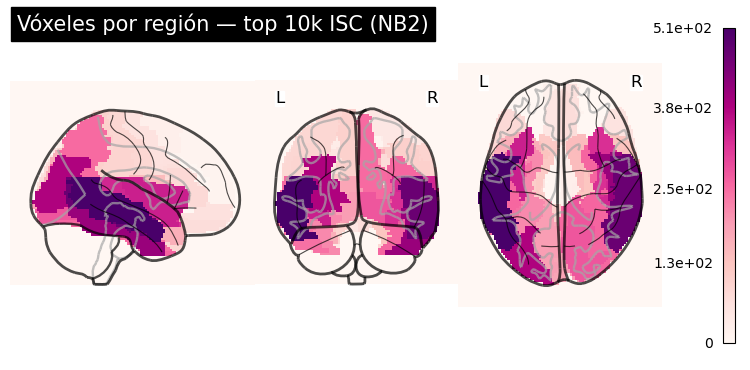

In [9]:
# Figura — regiones AAL coloreadas por nº de vóxeles
# Requiere una vez:  pip install nilearn   (la 1ª ejecución descarga el atlas AAL)
import numpy as np
from nilearn import datasets, image, plotting
from collections import Counter

# 1) Conteo región -> nº de vóxeles.
counts = Counter(roi_names[int(r) - 1] for r in top_10k_rois if r > 0)


# 2) Atlas AAL de nilearn (mismo convenio de nombres que el tuyo)
ssl._create_default_https_context = ssl._create_unverified_context
aal      = datasets.fetch_atlas_aal()
aal_img  = image.load_img(aal.maps)
aal_data = aal_img.get_fdata()

# 3) Volumen nuevo: cada región vale su nº de vóxeles
out = np.zeros_like(aal_data)
for name, idx in zip(aal.labels, aal.indices):   # idx son códigos del volumen (p.ej. 2001)
    if name in counts:
        out[aal_data == int(idx)] = counts[name]
out_img = image.new_img_like(aal_img, out)

# 4) Dibujar sobre cerebro transparente
plotting.plot_glass_brain(out_img, colorbar=True, cmap='RdPu',
                          title='Vóxeles por región — top 10k ISC (NB2)')
plotting.show()

[fetch_atlas_aal] Dataset found in C:\Users\Ale\nilearn_data\aal_3v2

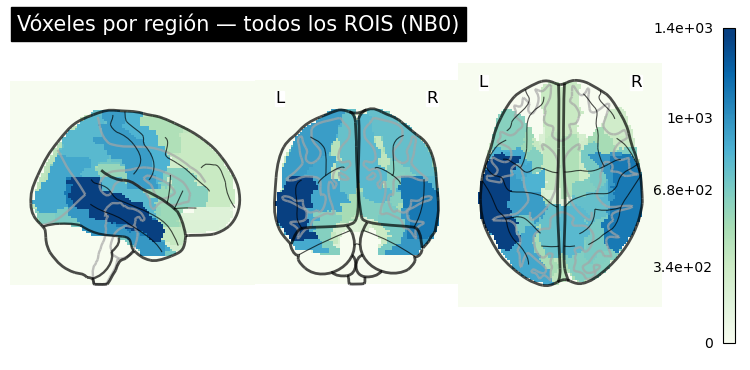

In [10]:
# Figura — regiones AAL coloreadas por nº de vóxeles
import numpy as np
from nilearn import datasets, image, plotting
from collections import Counter

# 1) Conteo región -> nº de vóxeles.
counts = Counter(roi_names[int(r) - 1] for r in col_to_roi if r > 0)

# 2) Atlas AAL de nilearn (mismo convenio de nombres que el tuyo)
ssl._create_default_https_context = ssl._create_unverified_context
aal      = datasets.fetch_atlas_aal()
aal_img  = image.load_img(aal.maps)
aal_data = aal_img.get_fdata()

# 3) Volumen nuevo: cada región vale su nº de vóxeles
out = np.zeros_like(aal_data)
for name, idx in zip(aal.labels, aal.indices):   # idx son códigos del volumen (p.ej. 2001)
    if name in counts:
        out[aal_data == int(idx)] = counts[name]
out_img = image.new_img_like(aal_img, out)

# 4) Dibujar sobre cerebro transparente
plotting.plot_glass_brain(out_img, colorbar=True, cmap= 'GnBu',
                          title='Vóxeles por región — todos los ROIS (NB0)')
plotting.show()

In [ ]:
#pip install -U certifi

In [9]:
#pip install pip-system-certs

Note: you may need to restart the kernel to use updated packages.
